# Resolve more sources than the number of sensors using a co-prime array

In [1]:
import numpy as np
import doatools.model as model
import doatools.estimation as estimation
import doatools.plotting as doaplt
import matplotlib.pyplot as plt
from doatools.plotting import plot_array
%matplotlib inline


In [2]:
np.random.seed(113)
wavelength = 1.0 # normalized
d0 = wavelength / 2

power_source = 1.0 # Sources share the same power.
power_noise = 1.0 # SNR = 0 dB
n_snapshots = 1024

## CPA Array
*Note: This co-prime array only have 9 elements.*


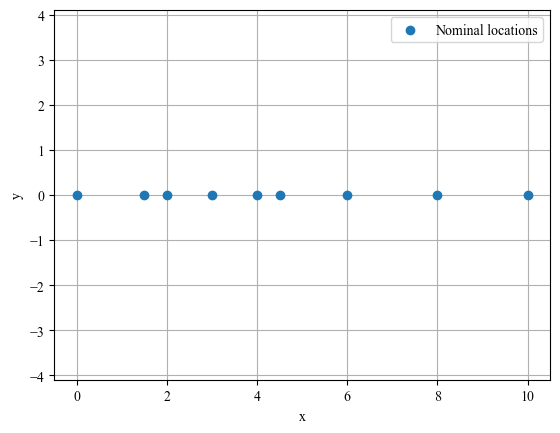

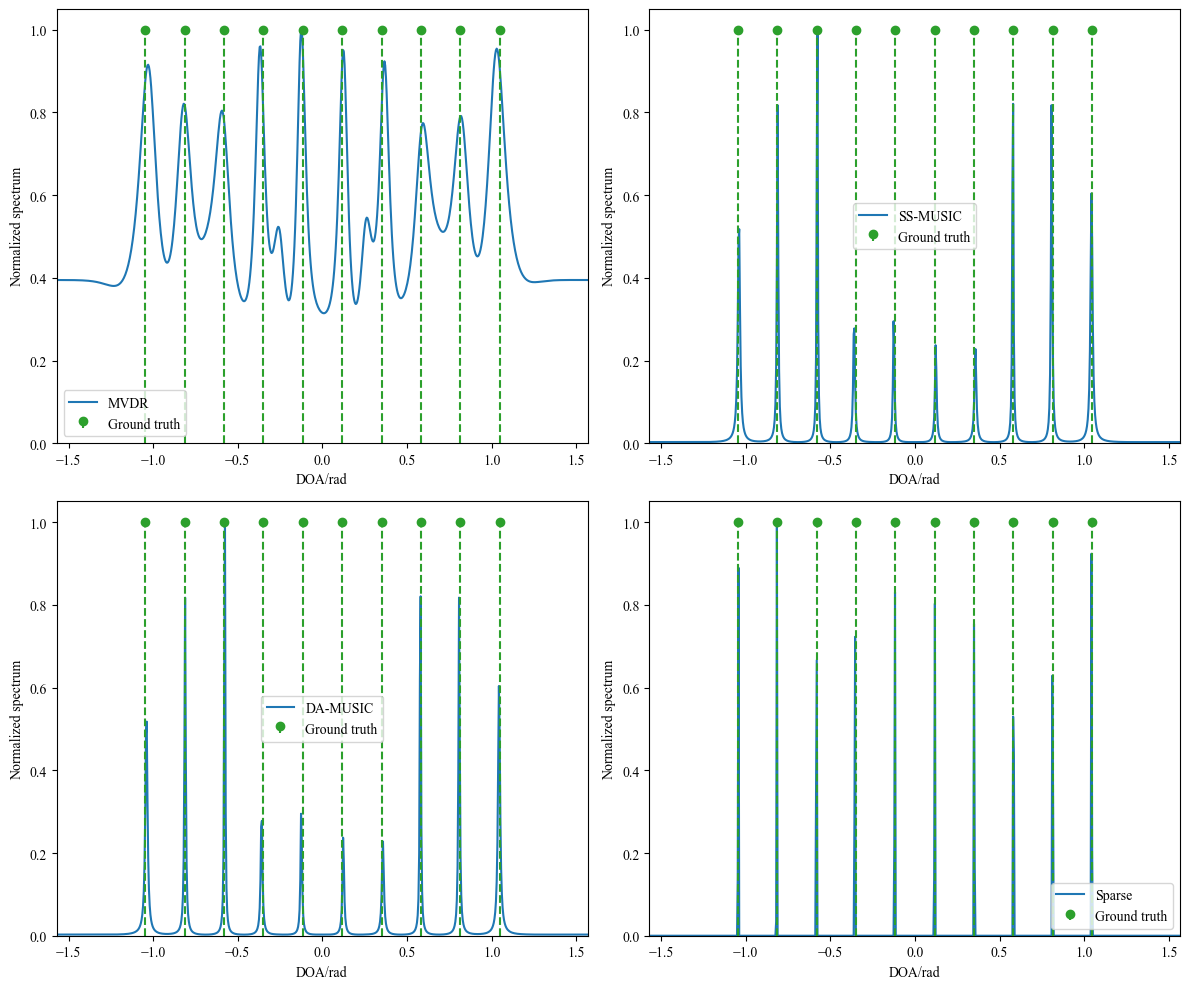

In [3]:
cpa = model.CoPrimeArray(3, 4, d0)
# However, we have 10 sources here.
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 10)
)
# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(cpa.size, power_noise)
y, R = model.get_narrowband_snapshots(
    cpa, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 
# Prepare the search grid.
grid = estimation.FarField1DSearchGrid(size=720)

# MVDR estimator: We assume that the number of sources is known.
mvdr = estimation.MVDRBeamformer(cpa, wavelength, grid)
resv_mvdr, est_mvdr, sp_mvdr = mvdr.estimate(R, sources.size, return_spectrum=True)

# DA-MUSIC/SS-MUSIC estimator: We assume that the number of sources is unknown.
acm_builder = estimation.CoarrayACMBuilder1D(cpa)
virtual_ula = acm_builder.get_virtual_ula()
Rss = acm_builder.transform(R, 'ss')
Rda = acm_builder.transform(R, 'da')
music = estimation.MUSIC(virtual_ula, wavelength, grid)
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)

# Sparse covariance matching estimator: We assume that the number of sources is unknown.
scm = estimation.GroupSparseEstimator(cpa, wavelength, grid, n_snapshots=len(cpa.element_indices))
resv_sr, est_sr, sp_sr = scm.estimate(R, sources.size, l = 8.0, return_spectrum=True,solver_options={"solver":"SCS"})


# Plot the results.
plot_array(cpa)

plt.figure(figsize=(12, 10)) 
ax = plt.subplot(2, 2, 1)
doaplt.plot_spectrum({'MVDR': sp_mvdr}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 2)
doaplt.plot_spectrum({'SS-MUSIC': sp_ss}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 3)
doaplt.plot_spectrum({'DA-MUSIC': sp_da}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 4)
doaplt.plot_spectrum({'Sparse': sp_sr}, grid, ax=ax, ground_truth=sources)
plt.tight_layout()
plt.show()

## Minimum Redundancy Linear Array (MRLA)
**MRLA** is a sparse array configuration that minimizes the number of sensors while maintaining the same array aperture as a uniform linear array (ULA).

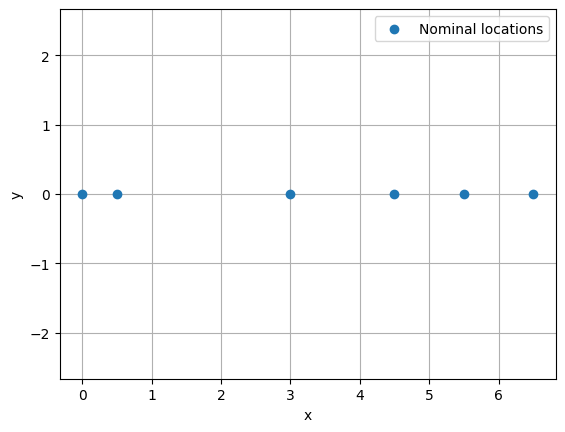

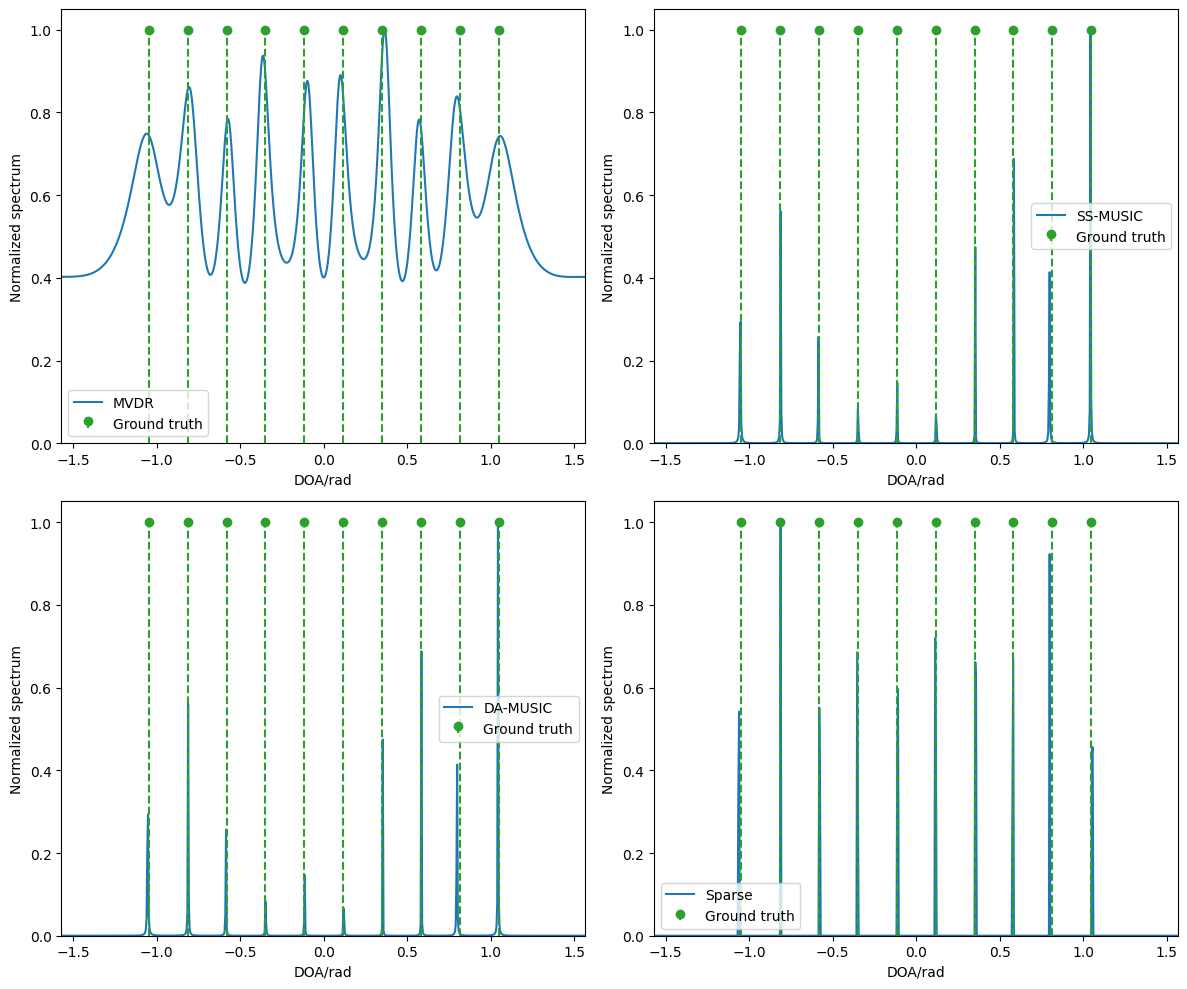

In [7]:
mrla = model.MinimumRedundancyLinearArray(6,d0)
# However, we have 10 sources here.
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 10)
)
# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(mrla.size, power_noise)
y, R = model.get_narrowband_snapshots(
    mrla, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 
# Prepare the search grid.
grid = estimation.FarField1DSearchGrid(size=720)

# MVDR estimator: We assume that the number of sources is known.
mvdr = estimation.MVDRBeamformer(mrla, wavelength, grid)
resv_mvdr, est_mvdr, sp_mvdr = mvdr.estimate(R, sources.size, return_spectrum=True)

# DA-MUSIC/SS-MUSIC estimator: We assume that the number of sources is unknown.
acm_builder = estimation.CoarrayACMBuilder1D(mrla)
virtual_ula = acm_builder.get_virtual_ula()
Rss = acm_builder.transform(R, 'ss')
Rda = acm_builder.transform(R, 'da')
music = estimation.MUSIC(virtual_ula, wavelength, grid)
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)

# Sparse covariance matching estimator: We assume that the number of sources is unknown.
scm = estimation.GroupSparseEstimator(mrla, wavelength, grid, n_snapshots=len(mrla.element_indices))
resv_sr, est_sr, sp_sr = scm.estimate(R, sources.size, l = 8.0, return_spectrum=True,solver_options={"solver":"SCS"})


# Plot the results.
plot_array(mrla)

plt.figure(figsize=(12, 10)) 
ax = plt.subplot(2, 2, 1)
doaplt.plot_spectrum({'MVDR': sp_mvdr}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 2)
doaplt.plot_spectrum({'SS-MUSIC': sp_ss}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 3)
doaplt.plot_spectrum({'DA-MUSIC': sp_da}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 4)
doaplt.plot_spectrum({'Sparse': sp_sr}, grid, ax=ax, ground_truth=sources)
plt.tight_layout()
plt.show()

## NestedArray
**NestedArray** 

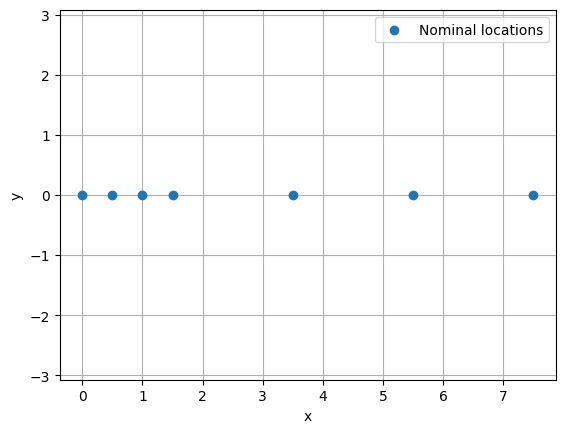

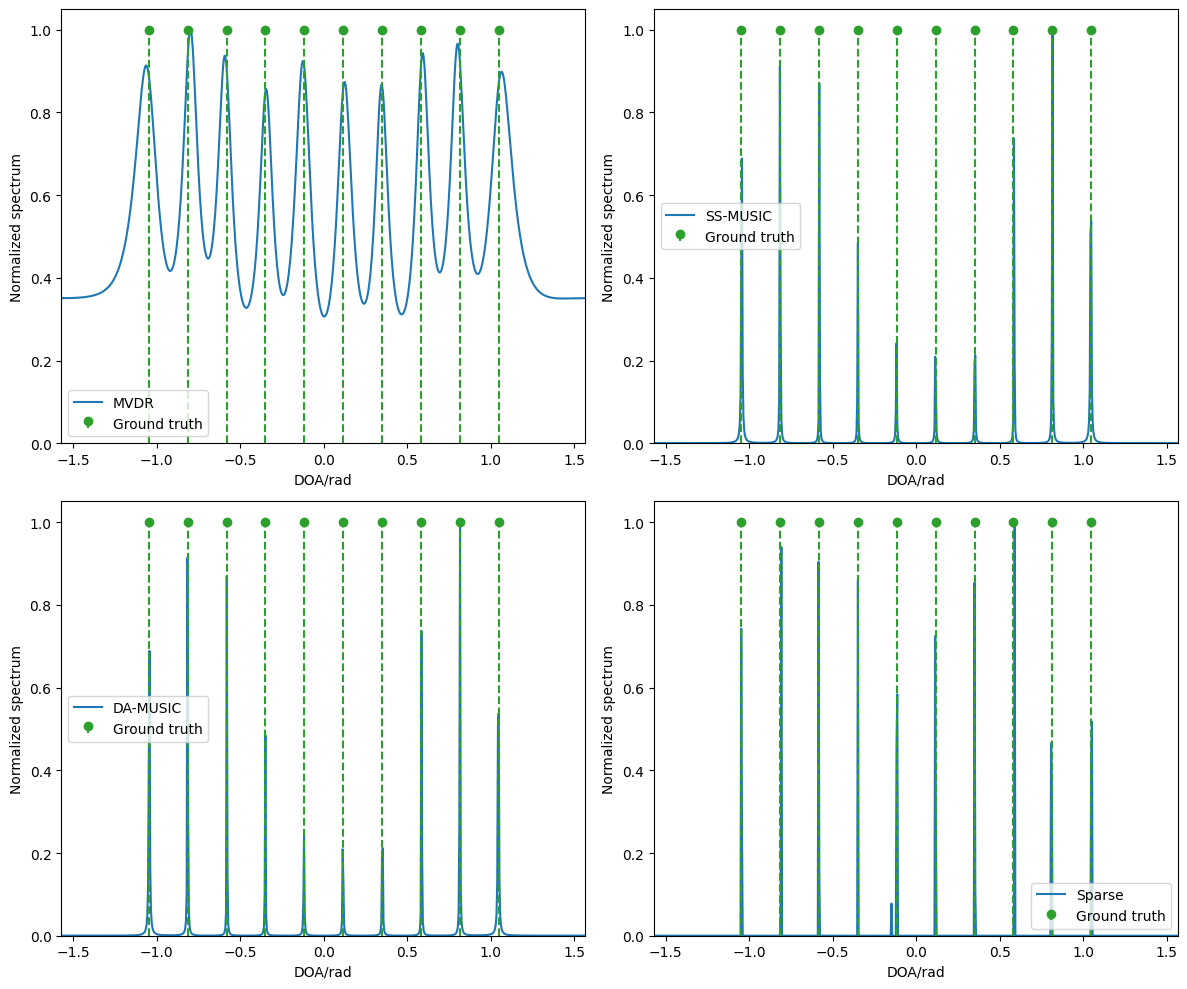

In [8]:
nla = model.NestedArray(3,4,d0)
# However, we have 10 sources here.
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 10)
)
# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(nla.size, power_noise)
y, R = model.get_narrowband_snapshots(
    nla, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 
# Prepare the search grid.
grid = estimation.FarField1DSearchGrid(size=720)

# MVDR estimator: We assume that the number of sources is known.
mvdr = estimation.MVDRBeamformer(nla, wavelength, grid)
resv_mvdr, est_mvdr, sp_mvdr = mvdr.estimate(R, sources.size, return_spectrum=True)

# DA-MUSIC/SS-MUSIC estimator: We assume that the number of sources is unknown.
acm_builder = estimation.CoarrayACMBuilder1D(nla)
virtual_ula = acm_builder.get_virtual_ula()
Rss = acm_builder.transform(R, 'ss')
Rda = acm_builder.transform(R, 'da')
music = estimation.MUSIC(virtual_ula, wavelength, grid)
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)

# Sparse covariance matching estimator: We assume that the number of sources is unknown.
scm = estimation.GroupSparseEstimator(nla, wavelength, grid, n_snapshots=len(nla.element_indices))
resv_sr, est_sr, sp_sr = scm.estimate(R, sources.size, l = 8.0, return_spectrum=True,solver_options={"solver":"SCS"})


# Plot the results.
plot_array(nla)

plt.figure(figsize=(12, 10)) 
ax = plt.subplot(2, 2, 1)
doaplt.plot_spectrum({'MVDR': sp_mvdr}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 2)
doaplt.plot_spectrum({'SS-MUSIC': sp_ss}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 3)
doaplt.plot_spectrum({'DA-MUSIC': sp_da}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 4)
doaplt.plot_spectrum({'Sparse': sp_sr}, grid, ax=ax, ground_truth=sources)
plt.tight_layout()
plt.show()

## NRLA非冗余稀疏阵列
**NRLA** is 

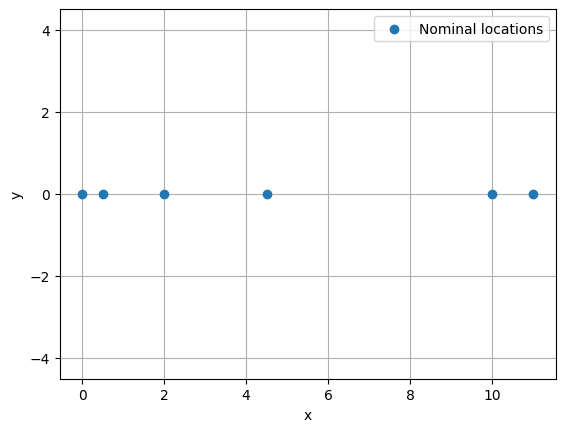

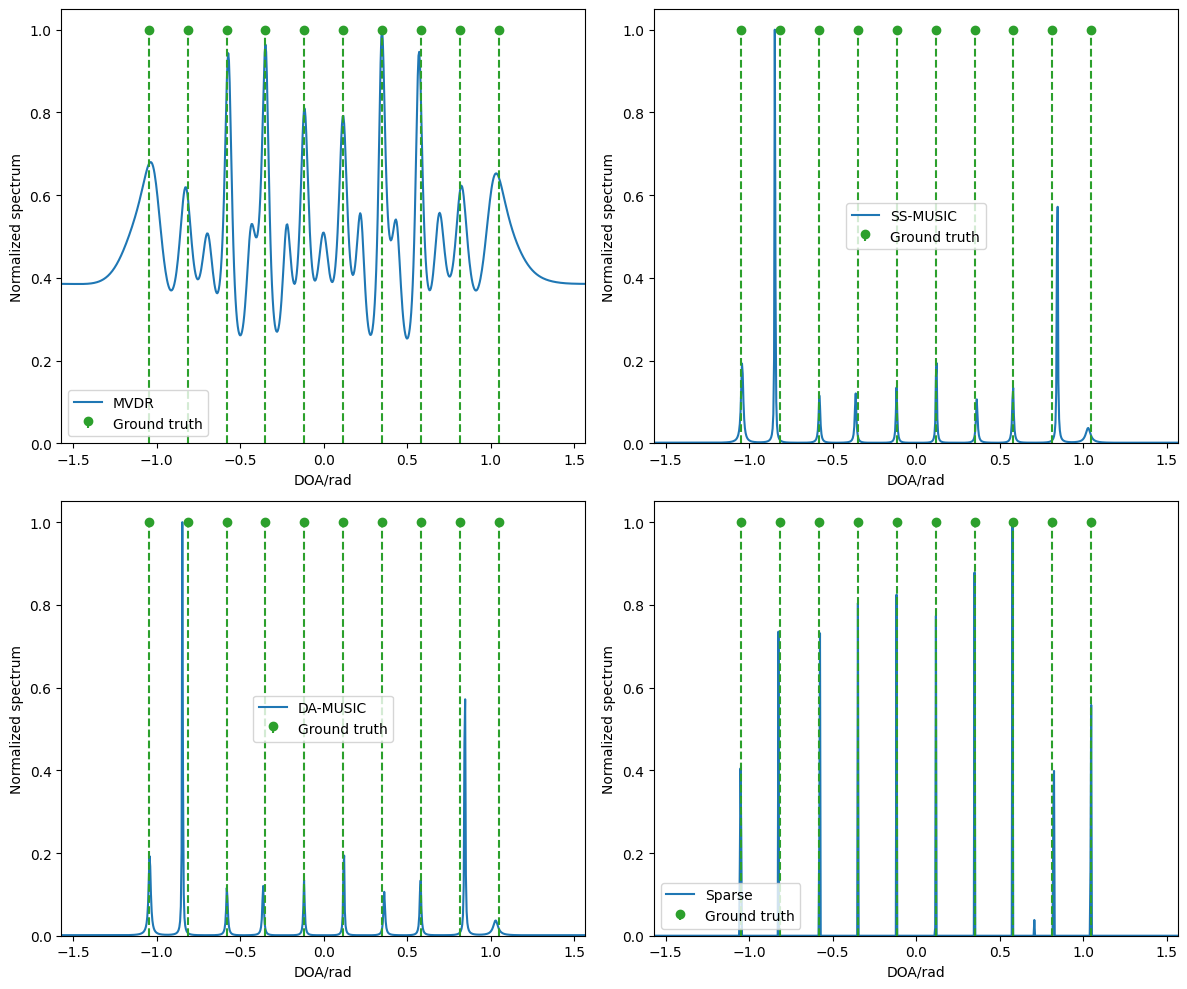

In [5]:
nrla = model.GridBasedArrayDesign(indices=np.array([0, 1, 4, 9, 20, 22])[:, np.newaxis], d0=d0, name='ONRA-da')
# However, we have 10 sources here.
sources = model.FarField1DSourcePlacement(
    np.linspace(-np.pi/3, np.pi/3, 10)
)
# Generate snapshots according to the stochastic model.
source_signal = model.ComplexStochasticSignal(sources.size, power_source)
noise_signal = model.ComplexStochasticSignal(nrla.size, power_noise)
y, R = model.get_narrowband_snapshots(
    nrla, sources, wavelength, source_signal, noise_signal,
    n_snapshots, return_covariance=True
) 
# Prepare the search grid.
grid = estimation.FarField1DSearchGrid(size=720)

# MVDR estimator: We assume that the number of sources is known.
mvdr = estimation.MVDRBeamformer(nrla, wavelength, grid)
resv_mvdr, est_mvdr, sp_mvdr = mvdr.estimate(R, sources.size, return_spectrum=True)

# DA-MUSIC/SS-MUSIC estimator: We assume that the number of sources is unknown.
acm_builder = estimation.CoarrayACMBuilder1D(nrla)
virtual_ula = acm_builder.get_virtual_ula()
Rss = acm_builder.transform(R, 'ss')
Rda = acm_builder.transform(R, 'da')
music = estimation.MUSIC(virtual_ula, wavelength, grid)
resv_ss, est_ss, sp_ss = music.estimate(Rss, sources.size, return_spectrum=True)
resv_da, est_da, sp_da = music.estimate(Rda, sources.size, return_spectrum=True)

# Sparse covariance matching estimator: We assume that the number of sources is unknown.
scm = estimation.GroupSparseEstimator(nrla, wavelength, grid, n_snapshots=len(nrla.element_indices))
resv_sr, est_sr, sp_sr = scm.estimate(R, sources.size, l = 8.0, return_spectrum=True,solver_options={"solver":"SCS"})


# Plot the results.
plot_array(nrla)

plt.figure(figsize=(12, 10)) 
ax = plt.subplot(2, 2, 1)
doaplt.plot_spectrum({'MVDR': sp_mvdr}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 2)
doaplt.plot_spectrum({'SS-MUSIC': sp_ss}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 3)
doaplt.plot_spectrum({'DA-MUSIC': sp_da}, grid, ax=ax, ground_truth=sources)
ax = plt.subplot(2, 2, 4)
doaplt.plot_spectrum({'Sparse': sp_sr}, grid, ax=ax, ground_truth=sources)
plt.tight_layout()
plt.show()